# Antisymmetrization

**In this notebook we:**
- briefly describe a procedure for initializing an "_antisymmetrized_" state over multiple registers of qubits
- demonstrate the use of a `Qubrick` as implemented in Workbench Algorithms corresponding to this procedure
- use a state vector sim to inspect and confirm that we indeed have prepared an antisymmetrized state

Consider a system of $\eta$ registers, each of size $\lceil \log N \rceil$. Suppose the initial state of these qubits is a tensor product of computational states, $|r_0 \dots r_{\eta - 1}⟩$. Further, assume the integers representing each basis state are *sorted* in ascending order, i.e. $r_0 < r_1 < \dots < r_{\eta - 1}$.

**We define an operation $\mathcal{A}$ which effects the following transformation:**

$$\mathcal{A} |r_0 \dots r_{\eta - 1}⟩ \rightarrow \sum_{\sigma \in S_{\eta}} (-1)^{\pi(\sigma)}|\sigma(r_0 \dots r_{\eta - 1})⟩$$

where $\sigma$ runs over all $S_{\eta} = \eta!$ possible permutations of the system registers, $|\sigma(r_0 \dots r_{\eta - 1})⟩$ denotes the state $|r_0 \dots r_{\eta - 1}⟩$ with the registers permuted according to $\sigma$, and ${\pi(\sigma)}$ is the parity of the permutation $\sigma$.

The resulting state above has the interesting property that if two of the registers undergo exchange with one another, the sign per basis state will flip from -1 to 1 (and vice-versa).

**We would now describe this state as being "_antisymmetrized_" and call $\mathcal{A}$ an "_antisymmetrizer_"**

### The procedure: key steps

We list various steps involved in the routine, which can later be easily identified when we execute a circuit using Workbench and visualize the circuit diagram. The technique referenced here (and which the `Qubrick` employs) was first introduced in [arXiv:1711.10460](https://arxiv.org/abs/1711.10460), and later optimized in [2204.11890](https://arxiv.org/abs/2204.11890). Here we only list the steps involved; for more detail, check out those two references.

**The antisymmetrization procedure works as follows:**
1. We prepare an auxiliary "seed" register in an equal superposition state.
2. We employ a sorting network on the seed register, keeping a record of all permutations made during the sort on another "record" register.
3. The seed register is measured in order to post-select on the collision-free subspace. If we observe a collision, we go back to step 1. If not, continue.
4. We apply Pauli Zs on each record qubit.
5. We use the record to reverse the sorting operations on the input system register, resulting in an equal superpotision of all permutations of the input state.
6. Because we applied Pauli Zs on each record qubit prior to the sort reversal, we also phase each permutation state according to its parity.

The above prepares the desired antisymmetrized state

**Let's see this in action.**

In [1]:
from psiqworkbench import QPU, vector_register, Qubrick
import numpy as np
from workbench_algorithms import BitonicSort, Antisymmetrizer
from workbench_algorithms.utils import total_sort_num_comps
from random import randint
import numpy as np

%load_ext autoreload

%autoreload 2

In [2]:
class SortedProductState(Qubrick):
    """Helper qubrick that will initialize a product state of sorted integers.

    Args:
        write_vals (list): List of integer values to write on each reg.
    """
    def __init__(self, write_vals, **kwargs):
        super().__init__(**kwargs)
        self.write_vals = write_vals

    def _compute(self, qbits):
        """Execute state prep circuit.

        Args:
            qbits (VectorRegister): List of qubit registers.
        """
        qbits.write(self.write_vals)

25


|tgt_0|tgt_1|tgt_2|?>


|0|1|2|.>    0.408248+0.000000j
|0|2|1|.>    -0.408248+0.000000j
|1|0|2|.>    -0.408248+0.000000j
|1|2|0|.>    0.408248+0.000000j
|2|0|1|.>    0.408248+0.000000j
|2|1|0|.>    -0.408248+0.000000j


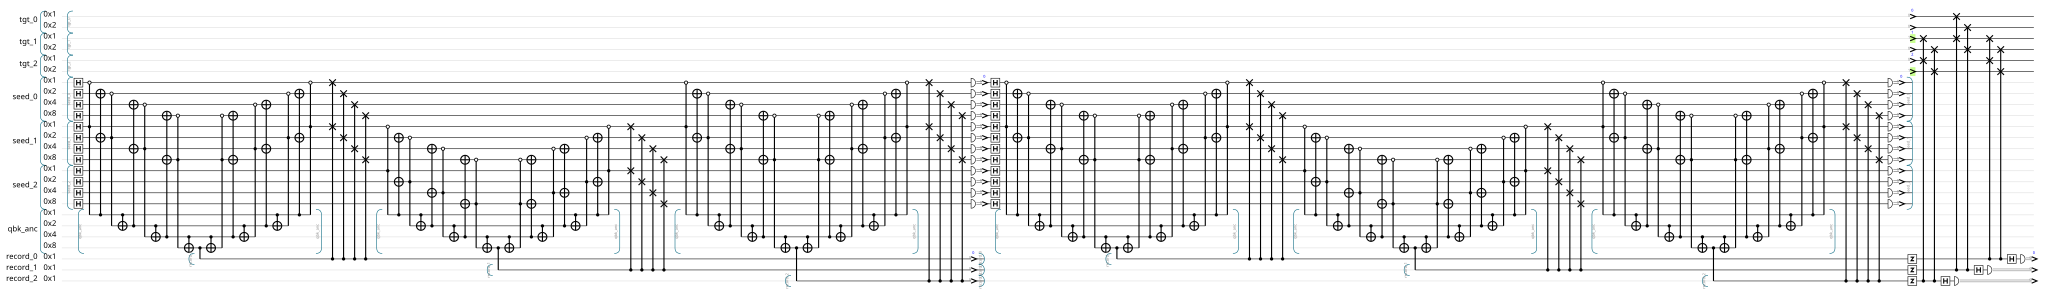

In [3]:
# choose number of registers
eta = 3

# set up num qubits
num_each_seed = int(np.ceil(np.log2(eta**2)))
num_seed = eta * num_each_seed
num_each_targ = int(np.ceil(np.log2(eta)))
num_target = eta * num_each_targ
num_record = total_sort_num_comps(eta)
num_anc = num_each_seed


# init QPU, allocate target reg
qc = QPU()
qc.reset(num_seed + num_target + num_record + num_anc)
print(qc.num_qubits)
target_reg = vector_register(qc, "tgt", eta * [num_each_targ])

# pass in sorted vals to write onto eta registers
write_vals = [i for i in range(eta)]
state_prep = SortedProductState(write_vals, qc=qc)

# set up Qubrick, execute circuit
antisymmetrizer = Antisymmetrizer(state_prep)
antisymmetrizer.compute(target_reg)

# draw circuit, print state
qc.print_state_vector()
qc.draw()

#### Note
- If you re-run the above cell many times, you should notice that the circuit is sometimes longer, sometimes shorter. This is for two reasons:
  - The above procedure is actually implemented via postselection on the seed register's measured output (to ensure that there are no collisions after sorting).
  - The uncomputation of the record register uses the same uncomputation trick explained in the Bitonic sort jupyter notebook, which can result in fewer comparators.

### Visual verification

Looking at the cell above, see if you can visually identify all the steps of the procedure listed earlier. Also, does the resulting state look antisymmetrized to you? As a first indication, you could check if the number of nonzero amplitudes is what you expected, and whether the corresponding computational basis states are all permutations of each other.

We can convince ourselves even _further_ that this state is antisymmetrized by permuting registers one at a time and seeing if indeed the sign of each computational basis state flips from swap to swap.

In [4]:
# Should find that signs switch after swapping odd number of times
print('After one swap...')
qc.print_state_vector()
target_reg[0].swap(target_reg[1])

print()
print('... another one...')
# should see a sign change
qc.print_state_vector()

target_reg[0].swap(target_reg[2])

print()
print('... aaaaand another one!')
# should see a sign change yet again
qc.print_state_vector()

After one swap...
|tgt_0|tgt_1|tgt_2|?>


|0|1|2|.>    0.408248+0.000000j
|0|2|1|.>    -0.408248+0.000000j
|1|0|2|.>    -0.408248+0.000000j
|1|2|0|.>    0.408248+0.000000j
|2|0|1|.>    0.408248+0.000000j
|2|1|0|.>    -0.408248+0.000000j

... another one...
|tgt_0|tgt_1|tgt_2|?>


|0|1|2|.>    -0.408248+0.000000j
|0|2|1|.>    0.408248+0.000000j
|1|0|2|.>    0.408248+0.000000j
|1|2|0|.>    -0.408248+0.000000j
|2|0|1|.>    -0.408248+0.000000j
|2|1|0|.>    0.408248+0.000000j

... aaaaand another one!
|tgt_0|tgt_1|tgt_2|?>


|0|1|2|.>    0.408248+0.000000j
|0|2|1|.>    -0.408248+0.000000j
|1|0|2|.>    -0.408248+0.000000j
|1|2|0|.>    0.408248+0.000000j
|2|0|1|.>    0.408248+0.000000j
|2|1|0|.>    -0.408248+0.000000j


'|tgt_0|tgt_1|tgt_2|?>\n|0|1|2|.>    0.408248+0.000000j\n|0|2|1|.>    -0.408248+0.000000j\n|1|0|2|.>    -0.408248+0.000000j\n|1|2|0|.>    0.408248+0.000000j\n|2|0|1|.>    0.408248+0.000000j\n|2|1|0|.>    -0.408248+0.000000j\n'